#### Glass Classification

- This is a Glass Identification Data Set from UCI. It contains 10 attributes including id. The response is glass type(discrete 7 values)

- Data exploration of this dataset reveals two important characteristics :
1) The variables are highly corelated with each other including the response variables:
So which kind of ML algorithm is most suitable for this dataset Random Forest , KNN or other? Also since dataset is too small is there any chance of applying PCA or it should be completely avoided?

2) Highly Skewed Data:
Is scaling sufficient or are there any other techniques which should be applied to normalize data? Like BOX-COX Power transformation?

In [2]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#loading up the data
df = pd.read_csv('glass.csv')
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [4]:
#finding information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RI,214.0,1.518365,0.003037,1.51115,1.516522,1.51768,1.519157,1.53393
Na,214.0,13.407850,0.816604,10.73000,12.907500,13.30000,13.825000,17.38000
Mg,214.0,2.684533,1.442408,0.00000,2.115000,3.48000,3.600000,4.49000
Al,214.0,1.444907,0.499270,0.29000,1.190000,1.36000,1.630000,3.50000
Si,214.0,72.650935,0.774546,69.81000,72.280000,72.79000,73.087500,75.41000
K,214.0,0.497056,0.652192,0.00000,0.122500,0.55500,0.610000,6.21000
Ca,214.0,8.956963,1.423153,5.43000,8.240000,8.60000,9.172500,16.19000
Ba,214.0,0.175047,0.497219,0.00000,0.000000,0.00000,0.000000,3.15000
Fe,214.0,0.057009,0.097439,0.00000,0.000000,0.00000,0.100000,0.51000
Type,214.0,2.780374,2.103739,1.00000,1.000000,2.00000,3.000000,7.00000


In [6]:
df.isnull().sum
#conclusion: none of the variables in every column are null

<bound method DataFrame.sum of         RI     Na     Mg     Al     Si      K     Ca     Ba     Fe   Type
0    False  False  False  False  False  False  False  False  False  False
1    False  False  False  False  False  False  False  False  False  False
2    False  False  False  False  False  False  False  False  False  False
3    False  False  False  False  False  False  False  False  False  False
4    False  False  False  False  False  False  False  False  False  False
..     ...    ...    ...    ...    ...    ...    ...    ...    ...    ...
209  False  False  False  False  False  False  False  False  False  False
210  False  False  False  False  False  False  False  False  False  False
211  False  False  False  False  False  False  False  False  False  False
212  False  False  False  False  False  False  False  False  False  False
213  False  False  False  False  False  False  False  False  False  False

[214 rows x 10 columns]>

<Figure size 1000x600 with 0 Axes>

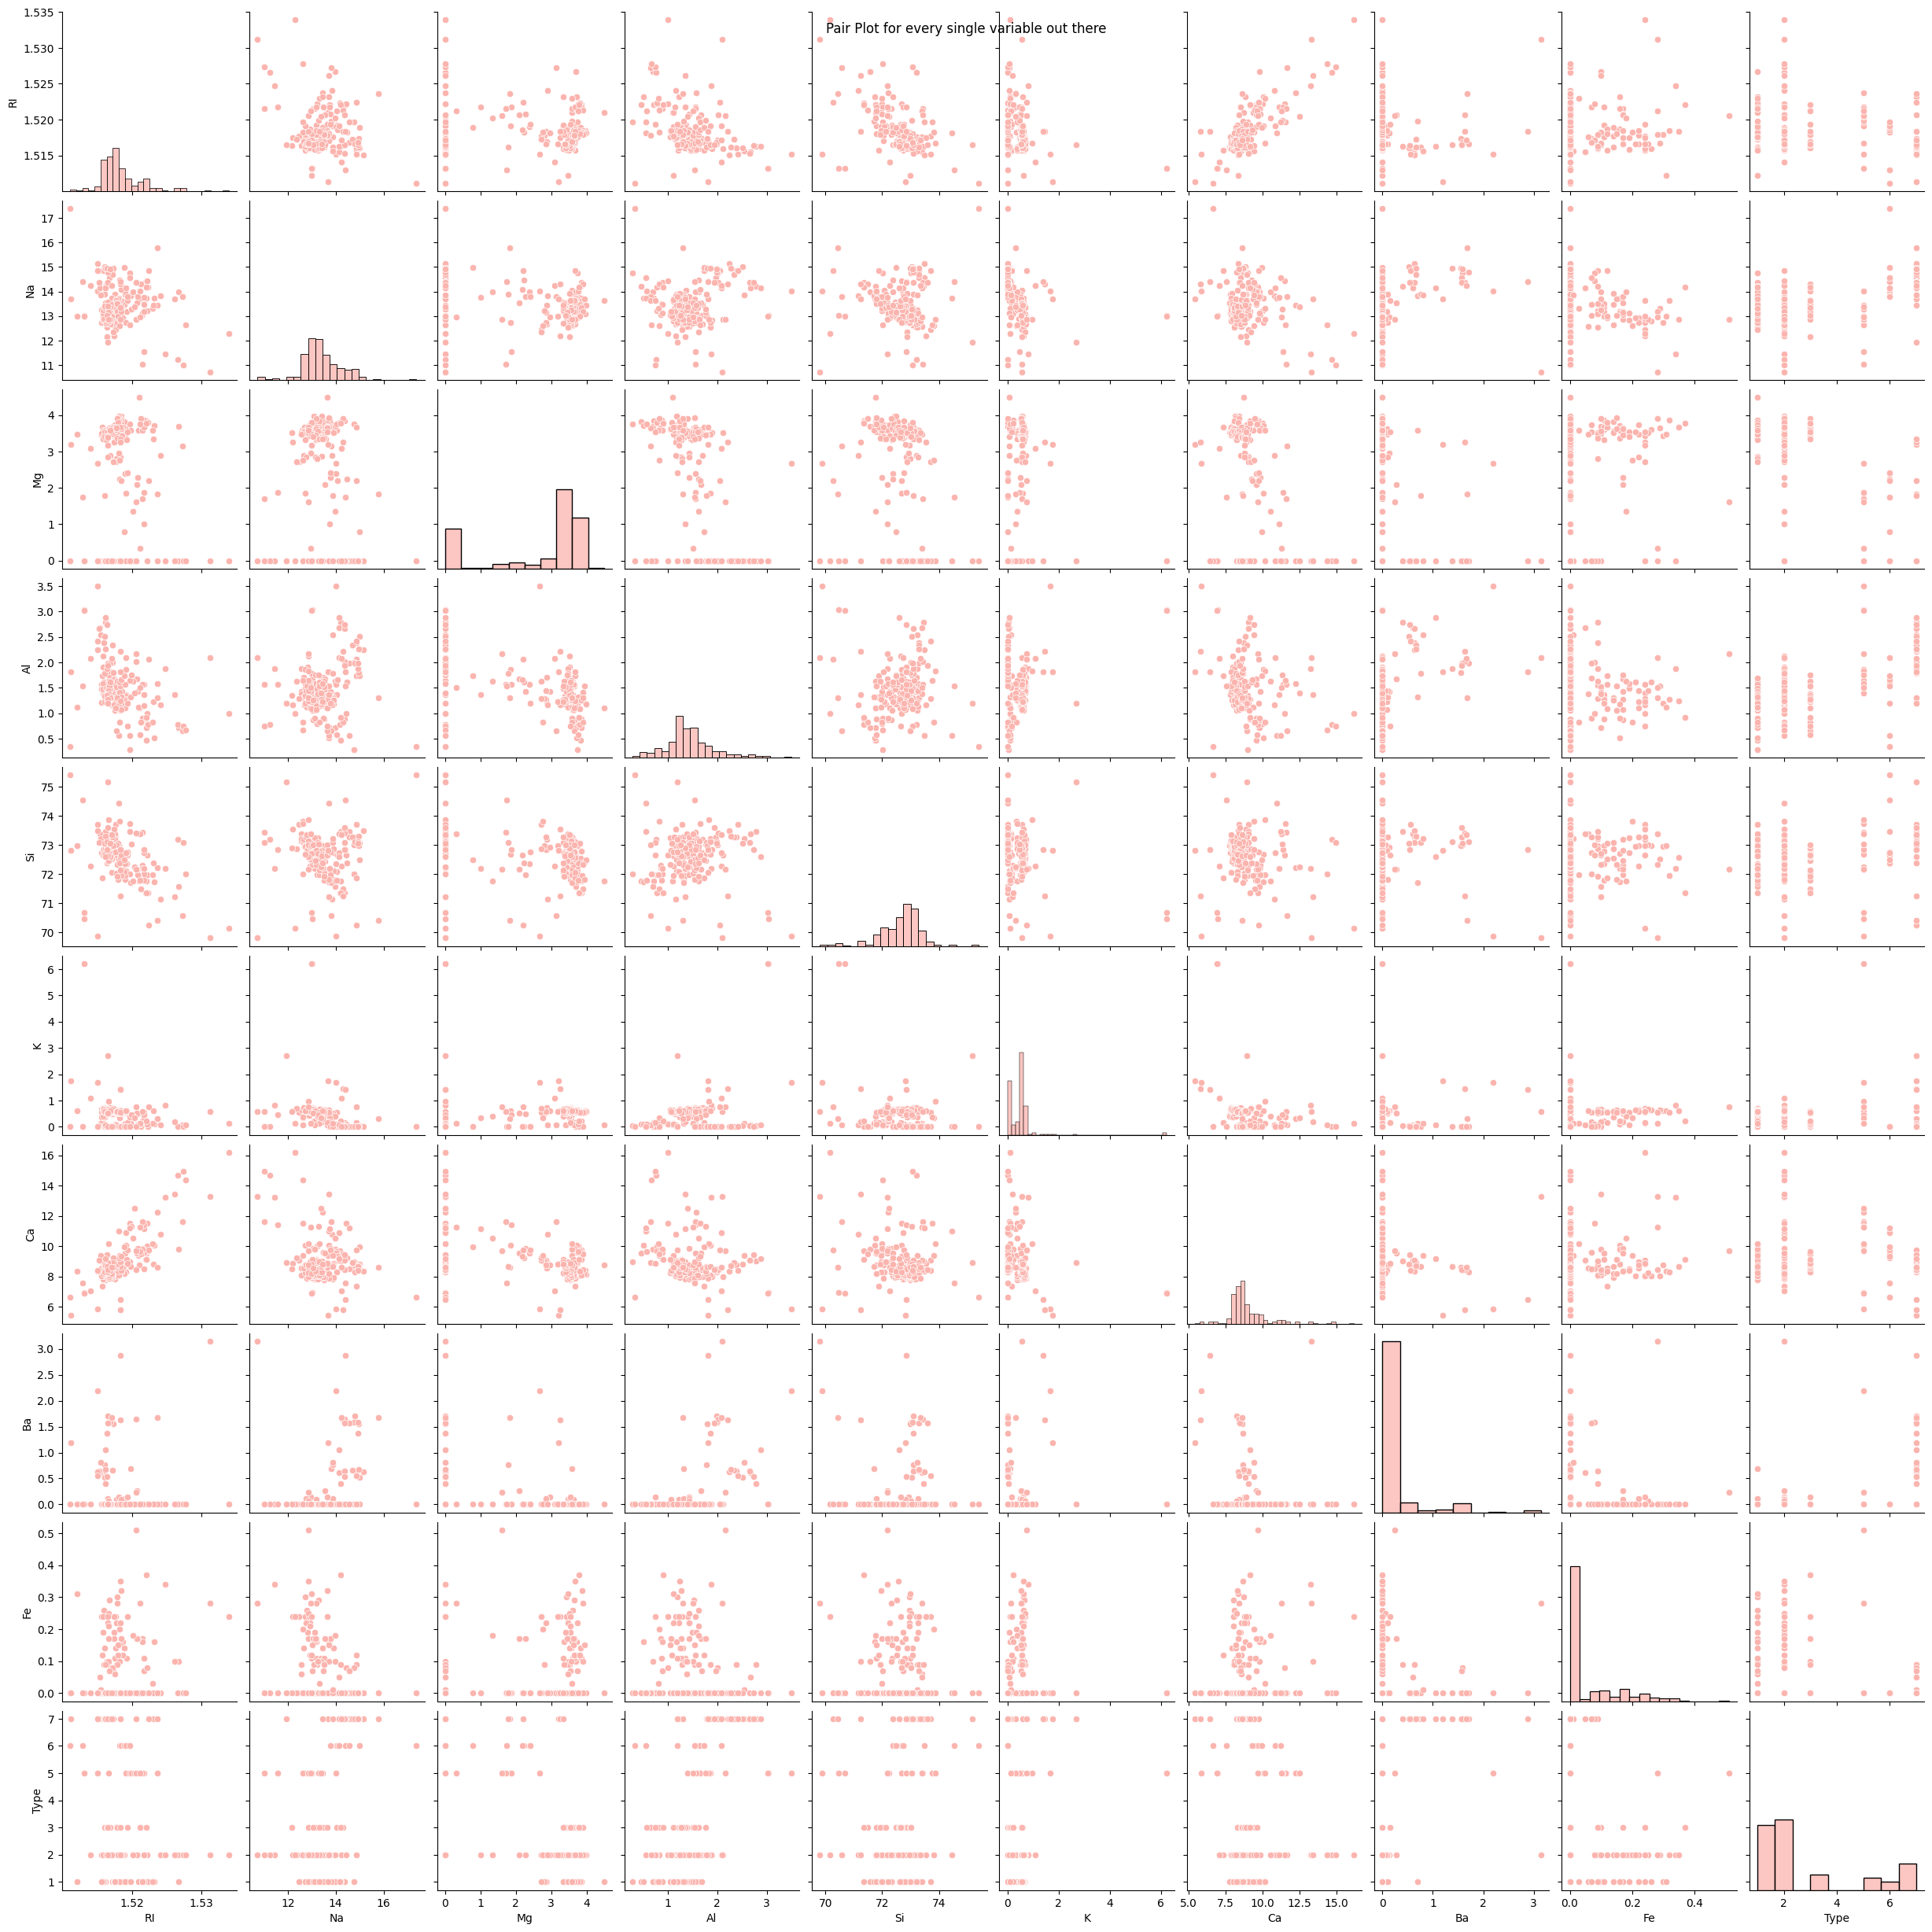

In [7]:
sns.set_palette("Pastel1")
plt.figure(figsize = (10,6))
sns.pairplot(df)
plt.suptitle("Pair Plot for every single variable out there")
plt.show()

#### Correlation
- We move on to checking for any correlations between any variables

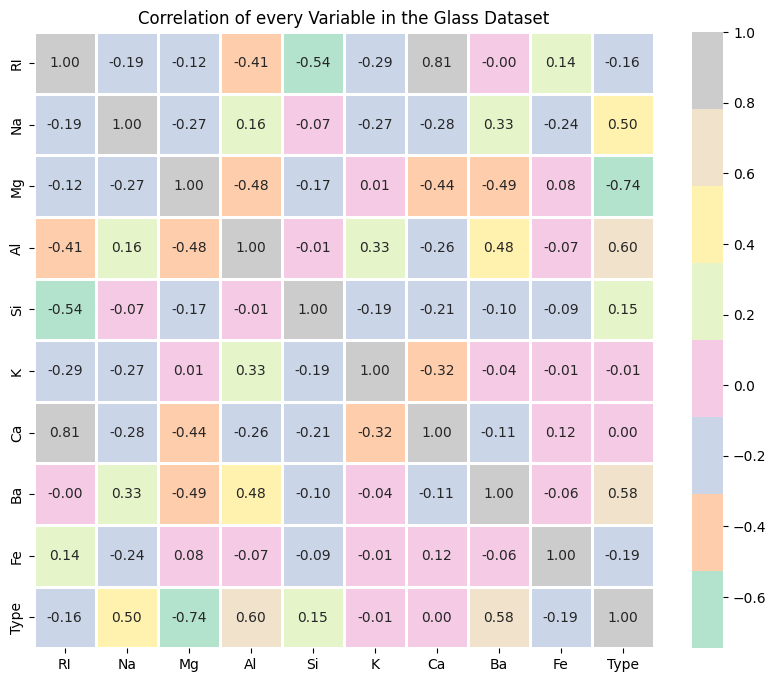

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,fmt='.2f',cmap = 'Pastel2',linewidth=2)
plt.title('Correlation of every Variable in the Glass Dataset')
plt.show()

In [16]:
y = df["Type"] #Tagret Value
X = df.drop("Type", axis=1) #Feature Values

#### Training and testing the dataset

In [32]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

#Feature Scaling - not needed for Random Forest as it's not highly sensitive to feature scaling
scaler = StandardScaler()


In [78]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.73      1.00      0.85        11
           2       0.83      0.71      0.77        14
           3       0.50      0.33      0.40         3
           5       1.00      0.75      0.86         4
           6       1.00      0.67      0.80         3
           7       0.89      1.00      0.94         8

    accuracy                           0.81        43
   macro avg       0.83      0.74      0.77        43
weighted avg       0.82      0.81      0.81        43



In [76]:
# Building the classifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
accuracy_score_table = []
cross_val_table = []

for i in range (1,21):

    classifier = RandomForestClassifier(n_estimators = i, random_state = 42)
    classifier.fit(X_train,y_train)


    y_pred = classifier.predict(X_test)
    
    accuracy = accuracy_score(y_pred,y_test)
    accuracy_score_table.append(accuracy)

    scores = cross_val_score(classifier, X, y, cv=5)
    mean_cross_val_table.append(scores.mean())
    
    print(f"Accuracy Score for n(estimator) = {i} : {accuracy}")
    print(f"Mean Cross Validation for n(estimator) = {i} : {scores.mean():3f}")
    print()


Accuracy Score for n(estimator) = 1 : 0.6976744186046512
Mean Cross Validation for n(estimator) = 1 : 0.504540

Accuracy Score for n(estimator) = 2 : 0.7209302325581395
Mean Cross Validation for n(estimator) = 2 : 0.578959

Accuracy Score for n(estimator) = 3 : 0.7906976744186046
Mean Cross Validation for n(estimator) = 3 : 0.630565

Accuracy Score for n(estimator) = 4 : 0.7906976744186046
Mean Cross Validation for n(estimator) = 4 : 0.663566

Accuracy Score for n(estimator) = 5 : 0.813953488372093
Mean Cross Validation for n(estimator) = 5 : 0.663677

Accuracy Score for n(estimator) = 6 : 0.7906976744186046
Mean Cross Validation for n(estimator) = 6 : 0.677519

Accuracy Score for n(estimator) = 7 : 0.8372093023255814
Mean Cross Validation for n(estimator) = 7 : 0.682171

Accuracy Score for n(estimator) = 8 : 0.813953488372093
Mean Cross Validation for n(estimator) = 8 : 0.672757

Accuracy Score for n(estimator) = 9 : 0.813953488372093
Mean Cross Validation for n(estimator) = 9 : 0.686

#### Evaluation 

In [81]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_pred,y_test)
print(f"Confusion Matrix: {conf_matrix}")

Confusion Matrix: [[11  3  1  0  0  0]
 [ 0 10  1  1  0  0]
 [ 0  1  1  0  0  0]
 [ 0  0  0  3  0  0]
 [ 0  0  0  0  2  0]
 [ 0  0  0  0  1  8]]


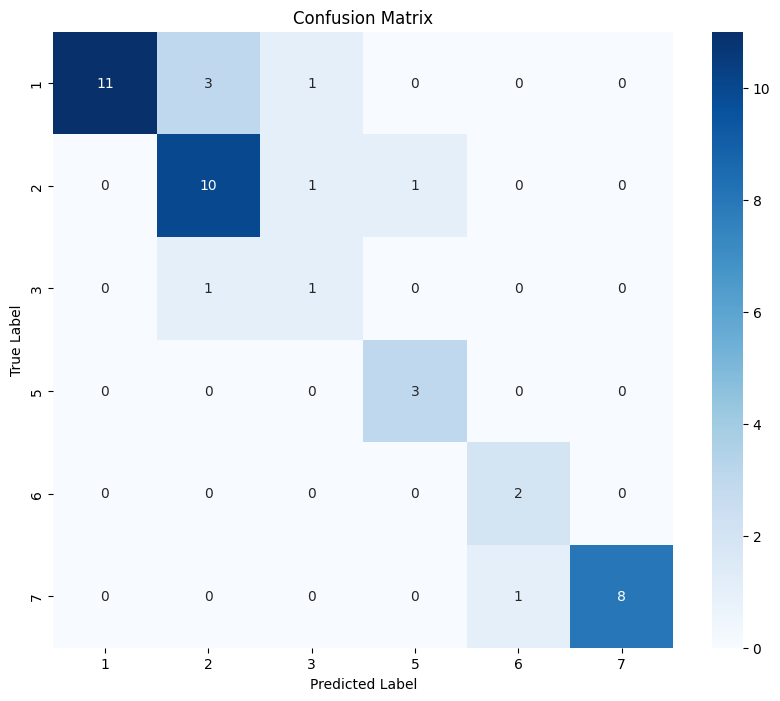

In [86]:
plt.figure(figsize=(10,8))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

<Figure size 1000x1200 with 0 Axes>

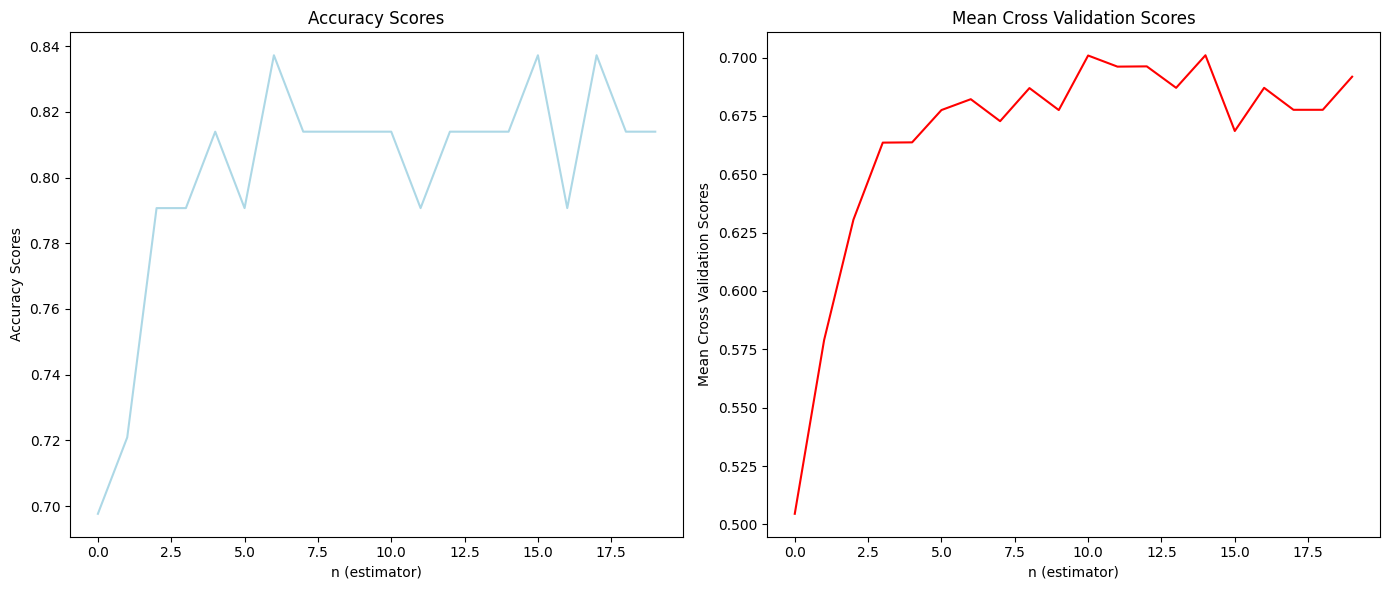

In [77]:
# Making a graph of my evaluation
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10,12))

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].plot(accuracy_score_table,c = "lightblue")
ax[0].set_title("Accuracy Scores")
ax[0].set_xlabel("n (estimator)")
ax[0].set_ylabel("Accuracy Scores")

ax[1].plot(mean_cross_val_table, c="red")
ax[1].set_title("Mean Cross Validation Scores")
ax[1].set_xlabel("n (estimator)")
ax[1].set_ylabel("Mean Cross Validation Scores")

plt.tight_layout()
plt.show()
